<a href="https://colab.research.google.com/github/haswanthkumar93/Assignment-03-bitsom_ba_2511972__Part-4-Data-Visualization-Machine-Learning/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import files
uploaded = files.upload()

Saving students.csv to students.csv


In [12]:
import pandas as pd

df = pd.read_csv("student_data.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv("students.csv")

# Define subject columns
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# 1. First 5 rows
print("1. First 5 rows:")
print(df.head())
print()

# 2. Shape and data types
print("2. Shape of dataset:", df.shape)
print("Data types:")
print(df.dtypes)
print()

# 3. Summary statistics
print("3. Summary statistics:")
print(df.describe())
print()

# 4. Pass/Fail count
print("4. Pass/Fail count:")
print(df['passed'].value_counts())
print()

# 5. Average scores per subject (pass vs fail)
print("5. Average scores - Passed students:")
print(df[df['passed'] == 1][subject_cols].mean())
print("\nAverage scores - Failed students:")
print(df[df['passed'] == 0][subject_cols].mean())
print()

# 6. Student with highest overall average
df['average'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['average'].idxmax()]
print("6. Top student (highest average):")
print(top_student)


1. First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

2. Shape of dataset: (15, 9)
Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

3. Summary statistics:
            math    sci

/tmp/ipykernel_5843/1891640550.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(box_data, labels=['Passed', 'Failed'], patch_artist=True,


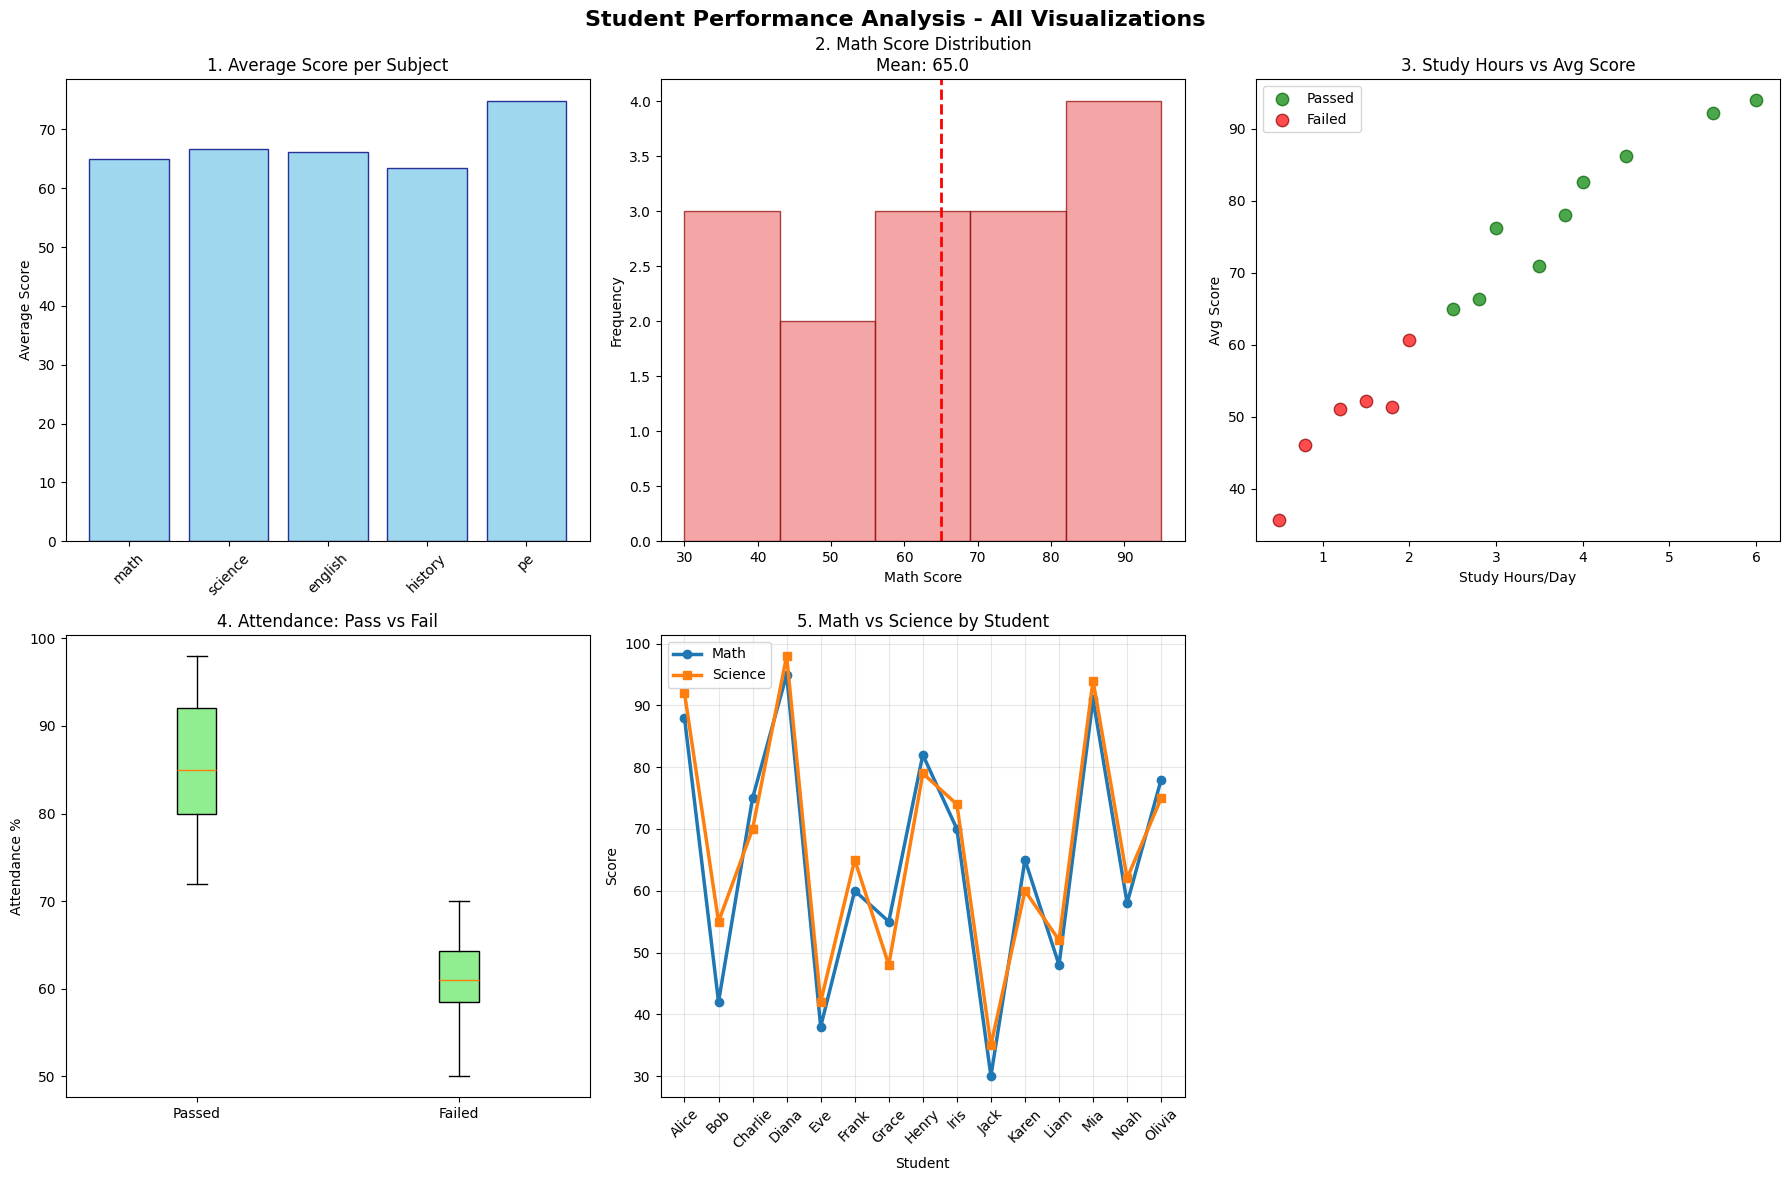

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Setup
df = pd.read_csv("students.csv")
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# Create all plots in subplots for professional presentation
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Student Performance Analysis - All Visualizations', fontsize=16, fontweight='bold')

# 1. BAR CHART
avg_scores = df[subject_cols].mean()
axes[0,0].bar(subject_cols, avg_scores, color='skyblue', edgecolor='navy', alpha=0.8)
axes[0,0].set_title('1. Average Score per Subject')
axes[0,0].set_ylabel('Average Score')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. HISTOGRAM
axes[0,1].hist(df['math'], bins=5, color='lightcoral', edgecolor='darkred', alpha=0.7)
mean_math = df['math'].mean()
axes[0,1].axvline(mean_math, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title(f'2. Math Score Distribution\nMean: {mean_math:.1f}')
axes[0,1].set_xlabel('Math Score')
axes[0,1].set_ylabel('Frequency')

# 3. SCATTER PLOT
passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]
axes[0,2].scatter(passed['study_hours_per_day'], passed['avg_score'],
                 color='green', s=80, alpha=0.7, label='Passed', edgecolors='darkgreen')
axes[0,2].scatter(failed['study_hours_per_day'], failed['avg_score'],
                 color='red', s=80, alpha=0.7, label='Failed', edgecolors='darkred')
axes[0,2].set_title('3. Study Hours vs Avg Score')
axes[0,2].set_xlabel('Study Hours/Day')
axes[0,2].set_ylabel('Avg Score')
axes[0,2].legend()

# 4. BOX PLOT
pass_att = df[df['passed'] == 1]['attendance_pct']
fail_att = df[df['passed'] == 0]['attendance_pct']
box_data = [pass_att, fail_att]
axes[1,0].boxplot(box_data, labels=['Passed', 'Failed'], patch_artist=True,
                 boxprops=dict(facecolor='lightgreen'))
axes[1,0].set_title('4. Attendance: Pass vs Fail')
axes[1,0].set_ylabel('Attendance %')

# 5. LINE PLOT
axes[1,1].plot(df['name'], df['math'], 'o-', linewidth=2.5, label='Math', markersize=6)
axes[1,1].plot(df['name'], df['science'], 's-', linewidth=2.5, label='Science', markersize=6)
axes[1,1].set_title('5. Math vs Science by Student')
axes[1,1].set_xlabel('Student')
axes[1,1].set_ylabel('Score')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Hide empty subplot
axes[1,2].remove()

plt.tight_layout()
plt.savefig('all_plots_combined.png', dpi=300, bbox_inches='tight')
plt.show()

# Individual plots (for assignment requirement)
# [Include the individual plt.savefig() calls from Version 1 here if needed]

/tmp/ipykernel_5843/402435955.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette="Blues")
/tmp/ipykernel_5843/402435955.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette="Greens")


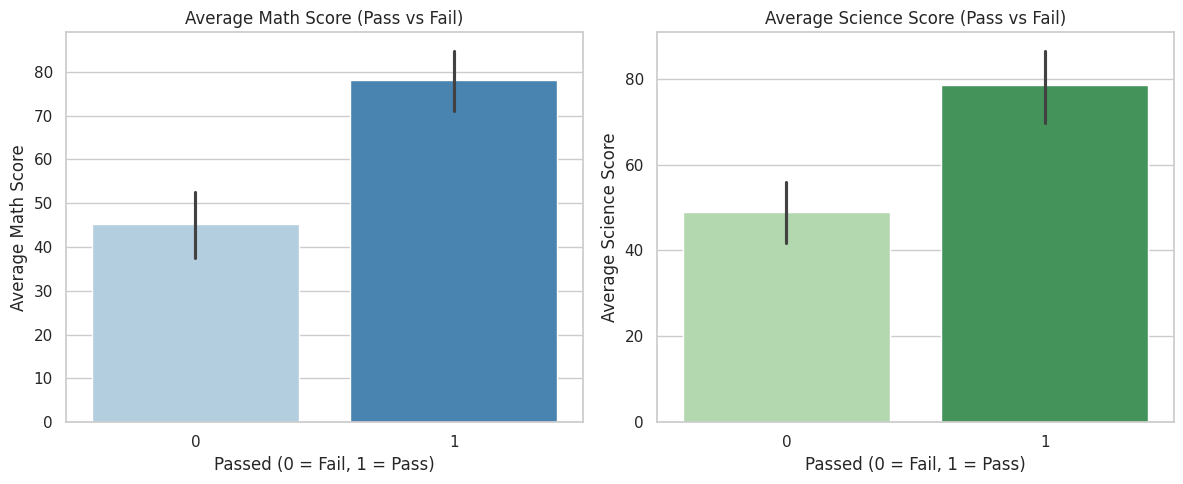

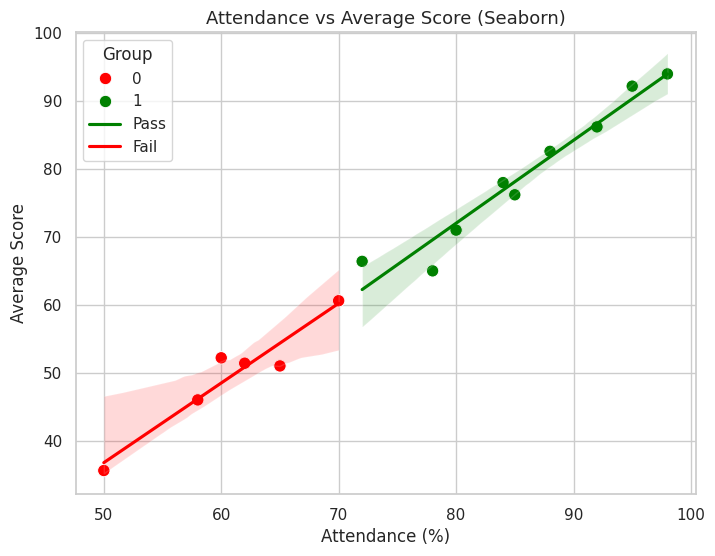

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("students.csv")

# Ensure avg_score exists
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# -------------------------------
# 1. BAR PLOTS (Math & Science)
# -------------------------------
plt.figure(figsize=(12, 5))

# Math bar plot
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette="Blues")
ax1.set_title("Average Math Score (Pass vs Fail)", fontsize=12)
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Average Math Score")

# Science bar plot
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2, palette="Greens")
ax2.set_title("Average Science Score (Pass vs Fail)", fontsize=12)
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Average Science Score")

plt.tight_layout()
plt.savefig("seaborn_barplots.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------
# 2. SCATTER + REGRESSION
# -------------------------------
plt.figure(figsize=(8, 6))

# Scatter with hue for pass/fail
sns.scatterplot(
    data=df,
    x='attendance_pct',
    y='avg_score',
    hue='passed',
    palette={0: "red", 1: "green"},
    s=80
)

# Regression lines for each group
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    color='green',
    label='Pass'
)
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    color='red',
    label='Fail'
)

plt.title("Attendance vs Average Score (Seaborn)", fontsize=13)
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend(title="Group")

plt.savefig("seaborn_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------
# 3. COMMENT (REQUIRED)
# -------------------------------
# For these plots, Seaborn felt more convenient than Matplotlib.
# The bar plots automatically used the mean values and nice default styling
# without extra code, and combining scatter + regression was straightforward
# using scatterplot and regplot on the same axes.

Train size: 12 samples
Test size:  3 samples

=== Model Performance ===
Training Accuracy: 1.000
Test Accuracy:     1.000

=== Test Predictions by Student ===
Jack            | Actual=0  Predicted=0  → ✅ Correct
Liam            | Actual=0  Predicted=0  → ✅ Correct
Alice           | Actual=1  Predicted=1  → ✅ Correct

=== Feature Importance (by |coefficient|) ===
Positive → pushes towards Pass, Negative → towards Fail
english         :  0.8125
attendance_pct  :  0.5219
study_hours_per_day:  0.4844
pe              :  0.4750
math            :  0.4379
science         :  0.3230
history         :  0.2629


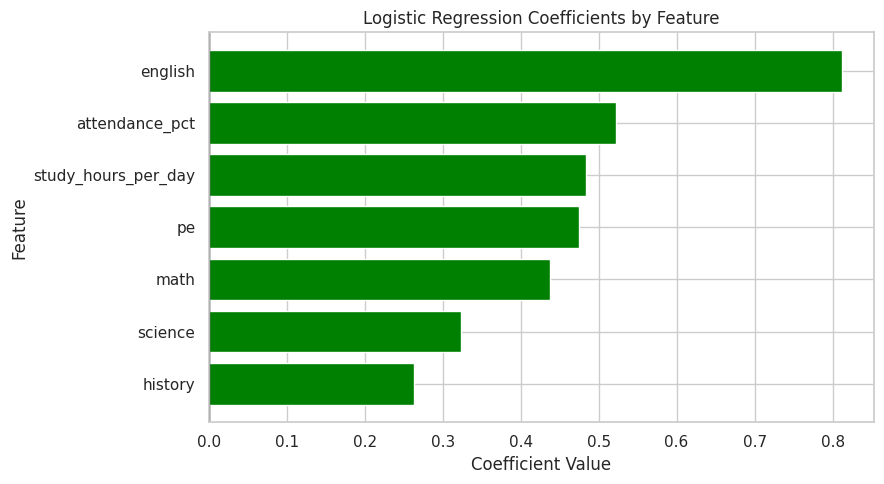


=== New Student Prediction ===
Input (math, science, english, history, pe, attendance_pct, study_hours_per_day):
[75, 70, 68, 65, 80, 82, 3.2]
Predicted label: Pass
Probability of Fail (0): 0.092
Probability of Pass (1): 0.908


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# STEP 0 — Load dataset
df = pd.read_csv("students.csv")

# STEP 1 — Prepare data (keep df intact, only exclude 'name' from X)
feature_cols = [
    'math', 'science', 'english', 'history', 'pe',
    'attendance_pct', 'study_hours_per_day'
]

X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

# Standardize features (very important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 2 — Train logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_preds = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_preds)
print("\n=== Model Performance ===")
print(f"Training Accuracy: {train_acc:.3f}")

# STEP 3 — Evaluate model on test set
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy:     {test_acc:.3f}")

print("\n=== Test Predictions by Student ===")
for i, idx in enumerate(X_test.index):
    name = df.loc[idx, 'name']
    actual = y_test.loc[idx]
    predicted = y_pred[i]
    status = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{name:15} | Actual={actual}  Predicted={predicted}  → {status}")

# STEP 4 — Feature importance from coefficients
coefficients = model.coef_[0]
feature_importance = list(zip(feature_cols, coefficients))
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n=== Feature Importance (by |coefficient|) ===")
print("Positive → pushes towards Pass, Negative → towards Fail")
for feature, coef in feature_importance:
    print(f"{feature:16}: {coef: .4f}")

# Horizontal bar chart
features = [f for f, _ in feature_importance]
values = [v for _, v in feature_importance]
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure(figsize=(9, 5))
plt.barh(features, values, color=colors)
plt.title("Logistic Regression Coefficients by Feature")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# STEP 5 — Predict result for a new student (bonus)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)
proba = model.predict_proba(new_student_scaled)[0]

label = "Pass" if prediction[0] == 1 else "Fail"

print("\n=== New Student Prediction ===")
print("Input (math, science, english, history, pe, attendance_pct, study_hours_per_day):")
print(new_student[0])
print(f"Predicted label: {label}")
print(f"Probability of Fail (0): {proba[0]:.3f}")
print(f"Probability of Pass (1): {proba[1]:.3f}")